# Part A — Big Data Analytics on DDoS Network Traffic

**Student:** Benjamine. S (258762A)
**Batch:** 18  
**Programme:** MSc Artificial Intelligence  
**University:** University of Moratuwa  
**Module:** Big Data Analytics Mini Project

---

## What This Notebook Does

This notebook analyses a real-world DDoS network traffic dataset using Apache Spark.
The dataset is the BCCC-cPacket-Cloud-DDoS-2024, published in March 2024 by York
University and cPacket Networks. It contains 540,494 network flow records with 319
features per flow, covering 17 DDoS attack types and 9 categories of benign traffic.

The analysis answers five questions about the data:

1. How are the attack types distributed — which are common and which are rare?
2. What are the measurable traffic signatures of each attack type?
3. How do timing patterns differ across attack types?
4. Which TCP flag combinations are characteristic of each attack?
5. Which features most clearly separate attack from benign traffic?

---

## Dataset

**Name:** BCCC-cPacket-Cloud-DDoS-2024  
**Source:** York University / cPacket Networks (March 2024)  
**Access:** Kaggle — dhoogla/bccc-cpacket-cloud-ddos-2024  
**License:** CC-BY-SA-4.0  
**Size:** 540,494 flows × 319 features  
**Format:** Parquet (29.5 MB compressed)

## Section 0 — Environment Setup

In [1]:
# Install PySpark — required in every new Colab session [not needed in VENV]
# !pip install pyspark --quiet

# Core PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F       # column functions: avg, count, round, when, etc.
from pyspark.sql.window import Window        # for window functions like RANK() OVER

# Visualisation — only called on small aggregated results after .toPandas()
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:{os.environ['PATH']}"

# Verify
import subprocess
result = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(result.stderr)

print("All libraries imported successfully.")

# --- Create SparkSession ---
spark = SparkSession.builder \
    .appName("BCCC_DDoS_PartA") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# --- Confirm it started ---
print(f"Spark version  : {spark.version}")
print(f"App name       : {spark.sparkContext.appName}")
print(f"Shuffle parts  : {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Driver memory  : {spark.conf.get('spark.driver.memory')}")

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment Homebrew (build 17.0.19+0)
OpenJDK 64-Bit Server VM Homebrew (build 17.0.19+0, mixed mode, sharing)

All libraries imported successfully.


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/12 02:34:25 WARN Utils: Your hostname, Benjamines-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.66 instead (on interface en0)
26/05/12 02:34:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/12 02:34:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version  : 4.0.0
App name       : BCCC_DDoS_PartA
Shuffle parts  : 8
Driver memory  : 4g


## Section 1 — Data Loading

In [4]:
import os
import platform


HOME = os.path.expanduser("~")
KAGGLE_DIR = os.path.join(HOME, ".kaggle")
os.makedirs(KAGGLE_DIR, exist_ok=True)
print(f"Running on  : {platform.system()}")
print(f"Kaggle dir  : {KAGGLE_DIR}")

# --- Kaggle authentication ---
KAGGLE_TOKEN = os.environ.get('KAGGLE_TOKEN', '')

if not KAGGLE_TOKEN:
    print("\nWARNING: KAGGLE_TOKEN not set.")
    print("In terminal run: export KAGGLE_TOKEN=your_token_here")
    print("Then restart the notebook kernel.")
else:
    token_path = os.path.join(KAGGLE_DIR, "access_token")
    with open(token_path, 'w') as f:
        f.write(KAGGLE_TOKEN)
    os.chmod(token_path, 0o600)
    os.environ['KAGGLE_TOKEN'] = KAGGLE_TOKEN
    print("Kaggle credentials configured.")

    # --- Download dataset ---
    os.makedirs("./data", exist_ok=True)
    !kaggle datasets download \
        -d dhoogla/bccc-cpacket-cloud-ddos-2024 \
        --path ./data \
        --unzip --quiet

    DATA_PATH = "./data/bccc-cpacket-cloud-ddos-2024-merged.parquet"

    if os.path.exists(DATA_PATH):
        size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
        print(f"Dataset     : {DATA_PATH}")
        print(f"Size        : {size_mb:.1f} MB")

        # --- Load into Spark ---
        # Parquet embeds schema — no inferSchema scan needed
        df = spark.read.parquet(DATA_PATH)

        print(f"\nRows        : {df.count():,}")
        print(f"Columns     : {len(df.columns)}")

        # Register as SQL temp view for SparkSQL queries
        # This allows spark.sql("SELECT ... FROM ddos_raw")
        df.createOrReplaceTempView("ddos_raw")
        print("SQL view    : ddos_raw registered")
    else:
        print(f"File not found: {DATA_PATH}")
        print("Check that the download completed successfully.")

# Print schema to confirm all 319 features loaded with correct types
# df.printSchema()

Running on  : Darwin
Kaggle dir  : /Users/benjamine/.kaggle
Kaggle credentials configured.
Dataset URL: https://www.kaggle.com/datasets/dhoogla/bccc-cpacket-cloud-ddos-2024
License(s): CC-BY-SA-4.0
Dataset     : ./data/bccc-cpacket-cloud-ddos-2024-merged.parquet
Size        : 29.5 MB

Rows        : 540,494
Columns     : 319
SQL view    : ddos_raw registered


## Section 2 — Understanding the Label Structure

In [10]:
# --- label column: high-level category ---
print("=== LABEL column — high-level category ===")
spark.sql("""
    SELECT label,
           COUNT(*) AS flow_count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM ddos_raw
    GROUP BY label
    ORDER BY flow_count DESC
""").show(truncate=False)

# --- activity column: specific traffic scenario ---
print("=== ACTIVITY column — specific traffic scenario ===")
spark.sql("""
    SELECT activity,
           label,
           COUNT(*) AS flow_count
    FROM ddos_raw
    GROUP BY activity, label
    ORDER BY label, flow_count DESC
""").show(40, truncate=False)

# --- Count distinct values in each ---
n_labels     = df.select("label").distinct().count()
n_activities = df.select("activity").distinct().count()

print(f"Distinct label values    : {n_labels}")
print(f"Distinct activity values : {n_activities}")
print()
print("Decision: all EDA sections group by 'activity'")
print("'label' is only used in Section 8 for binary Attack vs Benign comparison")

=== LABEL column — high-level category ===
+----------+----------+-----+
|label     |flow_count|pct  |
+----------+----------+-----+
|Benign    |349178    |64.60|
|Attack    |170436    |31.53|
|Suspicious|20880     |3.86 |
+----------+----------+-----+

=== ACTIVITY column — specific traffic scenario ===


26/05/12 10:09:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 10:09:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 10:09:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 10:09:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 10:09:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 10:09:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 1

+--------------------------+----------+----------+
|activity                  |label     |flow_count|
+--------------------------+----------+----------+
|Attack-TCP-BYPass-V1      |Attack    |134110    |
|Attack-TCP-Flag-SYN       |Attack    |3147      |
|Attack-TCP-Flag-ACK       |Attack    |3135      |
|Attack-TCP-Flag-ACK-PSH   |Attack    |3109      |
|Attack-Killer-TCP         |Attack    |3046      |
|Attack-TCP-Valid-SYN      |Attack    |3003      |
|Attack-TCP-Flag-SYN-ACK   |Attack    |2990      |
|Attack-TCP-IGMP           |Attack    |2960      |
|Attack-TCP-Flag-MIX       |Attack    |2919      |
|Attack-Killall-v2         |Attack    |2824      |
|Attack-TCP-SYN            |Attack    |2739      |
|Attack-TCP-Control        |Attack    |2491      |
|Attack-TCP-Flag-SYN-TIME  |Attack    |980       |
|Attack-TCP-Flag-SYN-TFO   |Attack    |843       |
|Attack-TCP-Flag-OSYNP     |Attack    |758       |
|Attack-TCP-Flag-OSYN      |Attack    |757       |
|Attack-TCP-Flag-RST-ACK   |Att

### Finding — Label Structure

The dataset uses a two-level classification system. The `activity` column with
26 specific traffic scenarios is the correct grouping variable for all analysis.
Using `label` alone collapses 17 distinct attack types into one category.

**Class imbalance:** Attack-TCP-BYPass-V1 accounts for 134,110 flows — 78.6%
of all attack traffic. The remaining 16 attack types each contribute between
625 and 3,147 flows. This imbalance is acknowledged in the recommendation
system design — the hybrid approach combines co-occurrence signals (CF + ALS)
with feature-space similarity (content-based) so that minority attack types
with sparse interaction signals are still recommended based on their traffic
feature proximity to other attack types.

---
## Section 3 — Data Cleaning and Preprocessing

Based on the label structure inspection, the cleaning strategy is:

1. **Null check** — verify whether any nulls exist across all 319 columns
2. **Remove physically impossible records** — negative duration or zero packet count records indicate sensor errors
3. **Standardise strings** — trim whitespace from `label` and `activity` to prevent grouping anomalies
4. **Add derived column** — `is_attack` boolean for cleaner binary comparisons

In [13]:
# --- Step 1: Null check across all 319 columns ---
# Build a list of expressions — one COUNT per column
# This pattern is from the SparkSQL practical
print("Checking for nulls across all 319 columns...")

null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

# Collect the single result row and filter to columns with nulls
null_dict = null_counts.collect()[0].asDict()
cols_with_nulls = {k: v for k, v in null_dict.items() if v > 0}

if cols_with_nulls:
    print(f"Columns with nulls: {len(cols_with_nulls)}")
    for col_name, cnt in sorted(
        cols_with_nulls.items(), key=lambda x: x[1], reverse=True
    ):
        print(f"  {col_name:<45} {cnt:>8,} nulls")
else:
    print("No null values found in any column.")
    print("Expected: cPacket hardware sensors produce complete records.")

# --- Step 2: Remove physically impossible records ---
# Negative duration = sensor timestamp error
# Zero packet count = empty flow record
# Negative bytes_rate = physically impossible
df_clean = df.filter(
    (F.col("duration") >= 0) &
    (F.col("packets_count") > 0) &
    (F.col("bytes_rate") >= 0) &
    F.col("label").isNotNull() &
    F.col("activity").isNotNull()
)

# --- Step 3: Standardise string columns ---
# Trim whitespace that could silently break GROUP BY results
df_clean = df_clean \
    .withColumn("label", F.trim(F.col("label"))) \
    .withColumn("activity", F.trim(F.col("activity")))

# --- Step 4: Add derived boolean column ---
# is_attack = True for Attack flows, False for everything else
# Simplifies CASE WHEN logic in Section 8
df_clean = df_clean.withColumn(
    "is_attack",
    F.when(F.col("label") == "Attack", True).otherwise(False)
)

# --- Report ---
original = df.count()
cleaned  = df_clean.count()
removed  = original - cleaned

print(f"\nCleaning Summary")
print(f"  Original rows  : {original:,}")
print(f"  Cleaned rows   : {cleaned:,}")
print(f"  Rows removed   : {removed:,}")

# Register cleaned view — all EDA uses this from now on
df_clean.createOrReplaceTempView("ddos_clean")
print(f"\nRegistered: ddos_clean")
print("All EDA sections query from ddos_clean.")

Checking for nulls across all 319 columns...


No null values found in any column.
Expected: cPacket hardware sensors produce complete records.

Cleaning Summary
  Original rows  : 540,494
  Cleaned rows   : 540,494
  Rows removed   : 0

Registered: ddos_clean
All EDA sections query from ddos_clean.


## Section 4 — EDA Q1: Attack Type Distribution
**Technique:** Exploratory data analysis using `spark.sql()` with a window
function — `SUM(COUNT(*)) OVER ()` computes the grand total across all groups
in a single query without a subquery, enabling percentage calculation alongside
each group count.

=== Q1 — Activity Distribution ===
+--------------------------+----------+----------+------------+
|activity                  |label     |flow_count|pct_of_total|
+--------------------------+----------+----------+------------+
|Benign                    |Benign    |301014    |55.6924     |
|Attack-TCP-BYPass-V1      |Attack    |134110    |24.8125     |
|Benign-Web_Browsing_HTTP-S|Benign    |29376     |5.4350      |
|Suspicious                |Suspicious|20880     |3.8631      |
|Benign-Systemic           |Benign    |9342      |1.7284      |
|Benign-Telnet             |Benign    |4766      |0.8818      |
|Attack-TCP-Flag-SYN       |Attack    |3147      |0.5822      |
|Attack-TCP-Flag-ACK       |Attack    |3135      |0.5800      |
|Attack-TCP-Flag-ACK-PSH   |Attack    |3109      |0.5752      |
|Attack-Killer-TCP         |Attack    |3046      |0.5636      |
|Attack-TCP-Valid-SYN      |Attack    |3003      |0.5556      |
|Attack-TCP-Flag-SYN-ACK   |Attack    |2990      |0.5532      |
|Atta

26/05/12 11:08:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 11:08:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 11:08:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 11:08:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 11:08:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 11:08:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/12 1

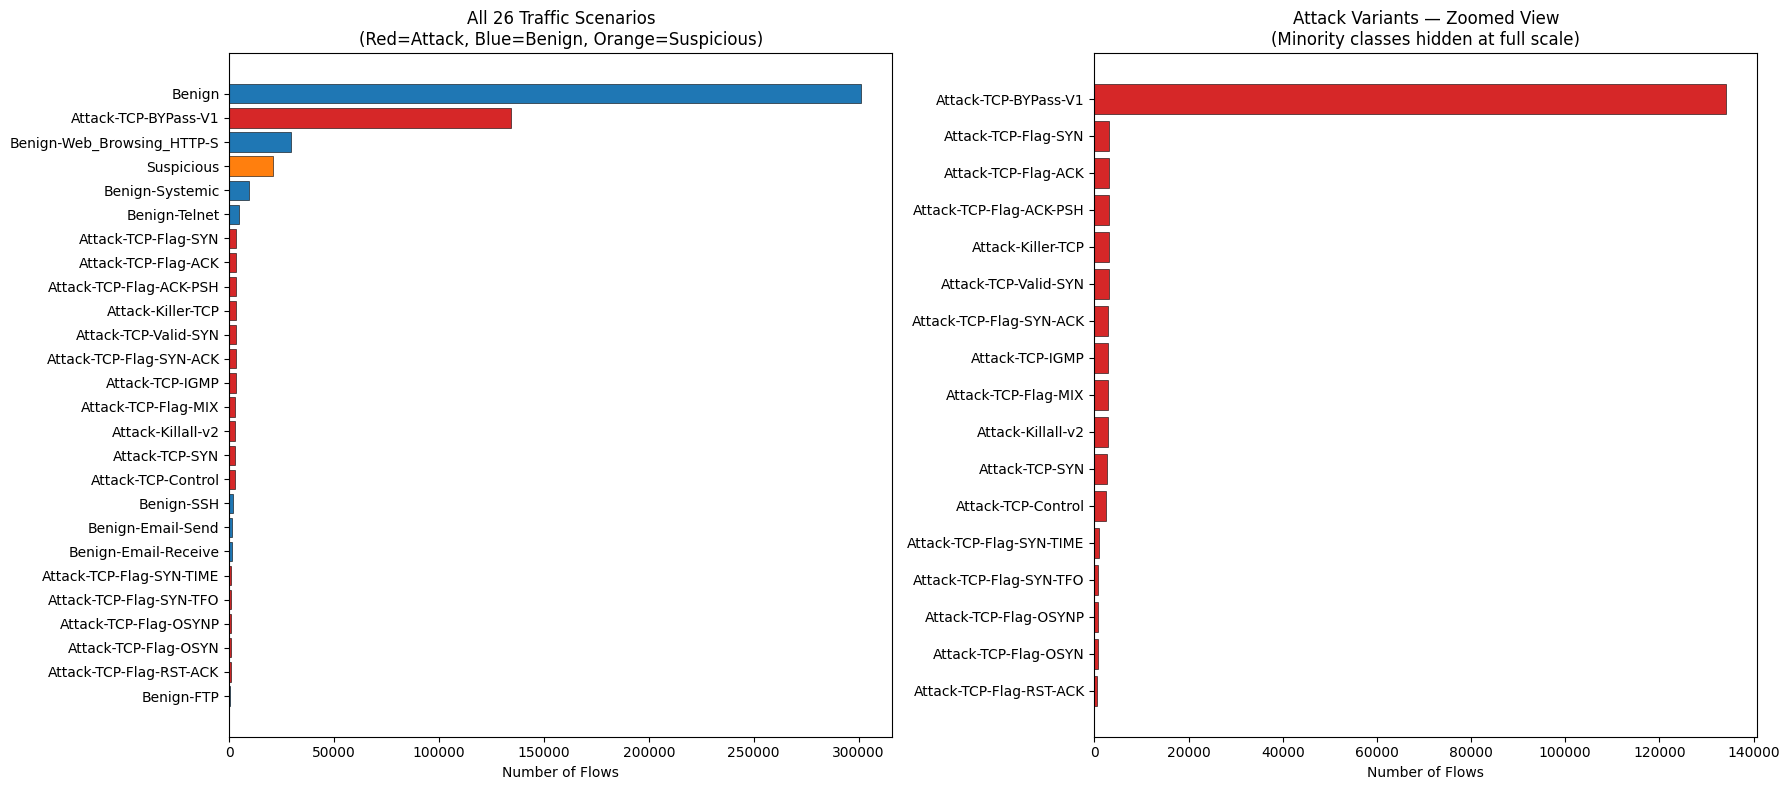

Saved: ./outputs/q1_attack_distribution.png


In [17]:
attack_dist = spark.sql("""
    SELECT
        activity,
        label,
        COUNT(*) AS flow_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4) AS pct_of_total
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY flow_count DESC
""")

print("=== Q1 — Activity Distribution ===")
attack_dist.show(30, truncate=False)

# --- Collect to pandas for visualisation ---
# Only the small 26-row aggregated result is collected
# The full 540k-row DataFrame stays distributed in Spark
dist_pd = attack_dist.toPandas()

# --- Chart ---
color_map = {
    'Attack':     '#d62728',
    'Benign':     '#1f77b4',
    'Suspicious': '#ff7f0e'
}
colors = dist_pd['label'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: all 26 scenarios
axes[0].barh(
    dist_pd['activity'],
    dist_pd['flow_count'],
    color=colors, edgecolor='black', linewidth=0.4
)
axes[0].set_xlabel('Number of Flows')
axes[0].set_title('All 26 Traffic Scenarios\n(Red=Attack, Blue=Benign, Orange=Suspicious)')
axes[0].invert_yaxis()

# Right: attack types only — zoomed to show minority classes
attack_only = dist_pd[dist_pd['label'] == 'Attack'].sort_values(
    'flow_count', ascending=True
)
axes[1].barh(
    attack_only['activity'],
    attack_only['flow_count'],
    color='#d62728', edgecolor='black', linewidth=0.4
)
axes[1].set_xlabel('Number of Flows')
axes[1].set_title('Attack Variants — Zoomed View\n(Minority classes hidden at full scale)')

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/q1_attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./outputs/q1_attack_distribution.png")